In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

filename = 'side_output.csv'
df = pd.read_csv(filename, header=None,index_col=0).T

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号
len(df)

65544

0.53%


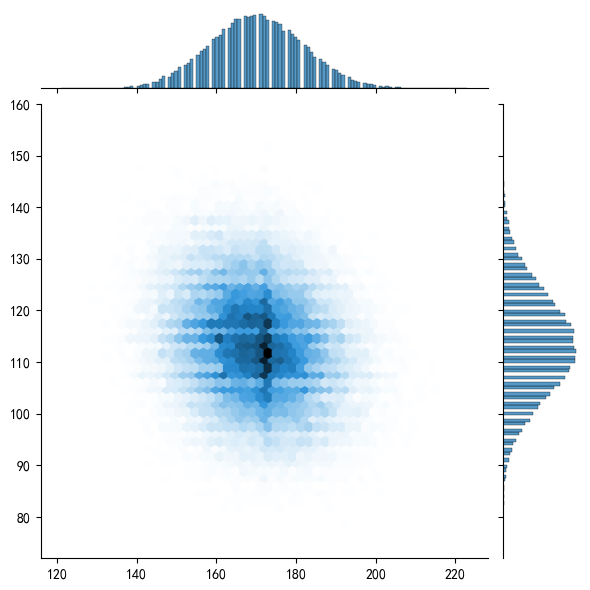

In [3]:
# 南瓜压力分析
df['XG']=df['BY'] # +df['HY']
N = len(df)

cnt = 0
for i in range(N):
    if df.iloc[i]['XG']>=199 and df.iloc[i]['KG']>=107:
        cnt = cnt+1
print(f'{100.0*cnt/N:.2f}%')

# 使用seaborn的联合分布图来可视化二维随机变量Z的经验分布
X = df['XG'].to_numpy()
Y = df['KG'].to_numpy()

Z = np.column_stack((X, Y))  # 将X和Y组合成一个二维数组

def empirical_distribution_function(data):
    data_sorted = np.sort(data, axis=0)
    edf = np.arange(1, N+1) / N
    return data_sorted, edf
X_sorted, X_edf = empirical_distribution_function(X)
Y_sorted, Y_edf = empirical_distribution_function(Y)

sns.jointplot(x=X, y=Y, kind='hex')
plt.show()